In [ ]:
<hr>
<h1>PROJECT 4 ON DENGUE ANALYSIS</h1>
<h5>ANALYST: MARK JOHN WELL D. DE CASTRO</h5>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import sklearn
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.read_csv("dengue.csv")

In [3]:
data['Month'] = data ['Month'].astype("category")
data['Region'] = data ['Region'].astype("category")

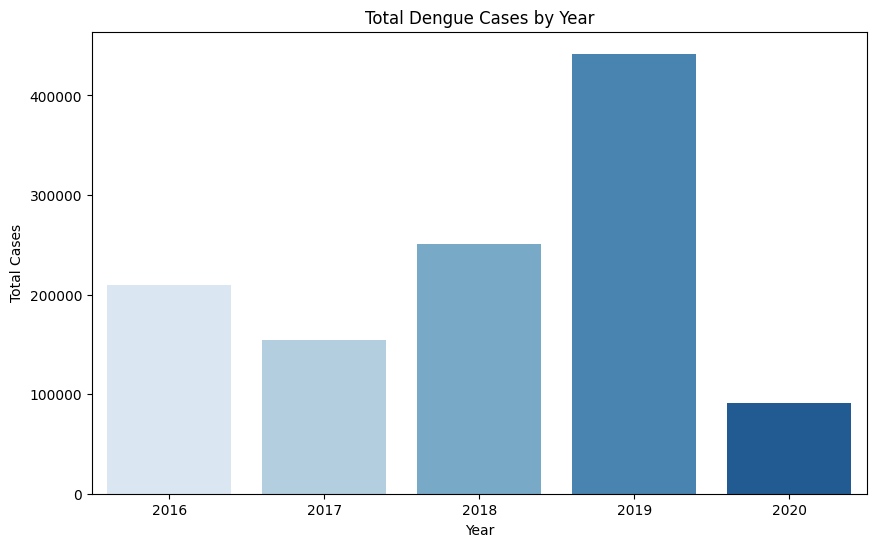

Year
2016    209544
2017    154155
2018    250783
2019    441902
2020     91041
Name: Dengue_Cases, dtype: int64


In [4]:
yearly_cases = data.groupby('Year')['Dengue_Cases'].sum()
plt.figure(figsize=(10, 6))
sns.barplot(x=yearly_cases.index, y=yearly_cases.values, palette='Blues')
plt.title('Total Dengue Cases by Year')
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.show()

print(f'{yearly_cases}')

<h1>INSIGHT 1:</h1>
<h3>The data shows a significant fluctuation in Dengue cases, with the highest peak in 2019 (441,902 cases) followed by a sharp decline in 2020 (91,041 cases), likely influenced by external factors such as climate or pandemic-related public health measures. This highlights the importance of understanding these patterns to better predict and manage future outbreaks.</h3>
<hr>

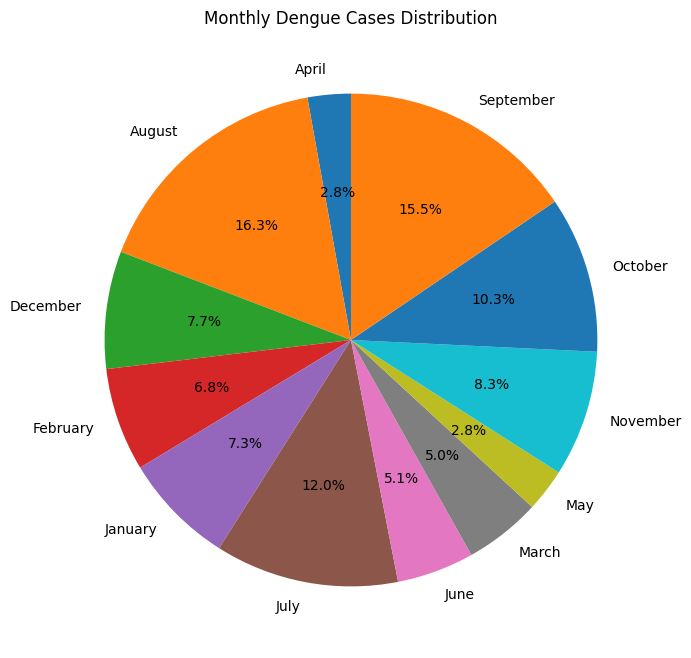

Month
April         32508
August       187554
December      88431
February      77801
January       84328
July         138242
June          58110
March         57576
May           32387
November      94900
October      117645
September    177943
Name: Dengue_Cases, dtype: int64


In [5]:
monthly_cases = data.groupby('Month')['Dengue_Cases'].sum().reindex()
plt.figure(figsize=(8, 8))
plt.pie(monthly_cases, labels=monthly_cases.index, autopct='%1.1f%%', startangle=90)
plt.title('Monthly Dengue Cases Distribution')
plt.show()

print(f'{monthly_cases}')

<h1>INSIGHT 2:</h1>
<h3>engue cases are highest in August (187,554) and September (177,943), showing a clear peak during the rainy season when mosquitoes thrive. The lowest cases occur in May (32,387), likely due to cooler or drier conditions that reduce mosquito breeding.</h3>
<hr>

In [6]:
m_dengue = data[data['Year'] == 2017]
monthly_distribution = m_dengue.groupby('Month')['Dengue_Cases'].sum()
monthly_distribution

Month
April         6343
August       25039
December     13235
February      9872
January      15623
July         18340
June          7589
March         7696
May           4853
November     12553
October      15259
September    17753
Name: Dengue_Cases, dtype: int64

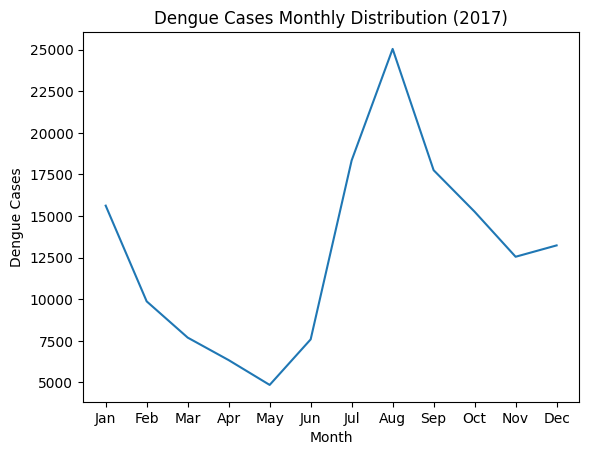

In [7]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 
          'Sep', 'Oct', 'Nov', 'Dec']
dengue_cases = [15623, 9872, 7696, 6343, 4853, 7589, 18340, 25039, 
                17753, 15259, 12553, 13235]

plt.plot(months, dengue_cases)
plt.xlabel('Month')
plt.ylabel('Dengue Cases')
plt.title('Dengue Cases Monthly Distribution (2017)')
plt.show()

<h1>INSIGHT 3:</h1>
<h3>In 2017, Dengue cases peaked in August (25,039) and were lowest in May (4,853), reflecting a seasonal trend with higher transmission during the rainy season. The sharp increase in mid-year suggests that environmental conditions like rainfall likely contributed to mosquito breeding and disease spread during this period.</h3>
<hr>

In [8]:
D_dengue = data[data['Year'] == 2017]
D_deaths = D_dengue.groupby('Month')['Dengue_Deaths'].sum()
D_deaths

Month
April          43
August        111
December       73
February       64
January        95
July           74
June           42
March          36
May            23
November       78
October      2098
September    1826
Name: Dengue_Deaths, dtype: int64

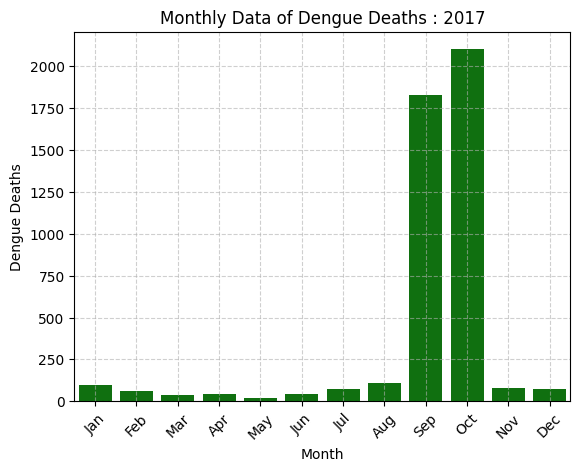

In [9]:

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 
          'Sep', 'Oct', 'Nov', 'Dec']

dengue_deaths = [95, 64, 36, 43, 23, 42, 74, 111, 1826, 2098, 78, 73]

sns.barplot(x=months, y=dengue_deaths, color='Green')

plt.xlabel('Month')
plt.ylabel('Dengue Deaths')
plt.title('Monthly Data of Dengue Deaths : 2017')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.show()

<h1>INSIGHT 4:</h1>
<h3>he data shows that dengue deaths remained relatively low throughout most of the year but rose sharply in September and October. This significant increase may indicate unusual conditions or events that contributed to the heightened mortality during these months.</h3>
<hr>

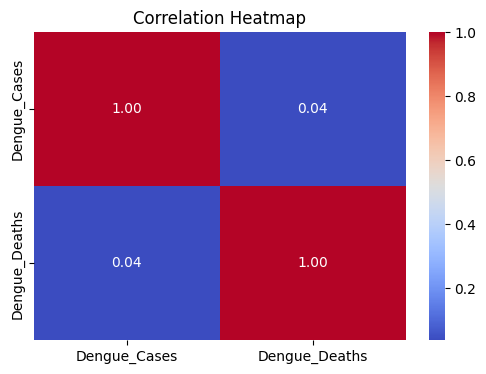

In [10]:
correlation_matrix = data[['Dengue_Cases', 'Dengue_Deaths']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

<h1>INSIGHT 5:</h1>
<h3>The correlation heatmap shows a very weak positive correlation (0.04) between Dengue cases and Dengue deaths, indicating that the number of cases does not strongly predict the number of deaths. This suggests that other factors, such as healthcare access, treatment quality, or underlying health conditions, may play a more significant role in determining mortality rates rather than just the total number of infections.</h3>
<hr>

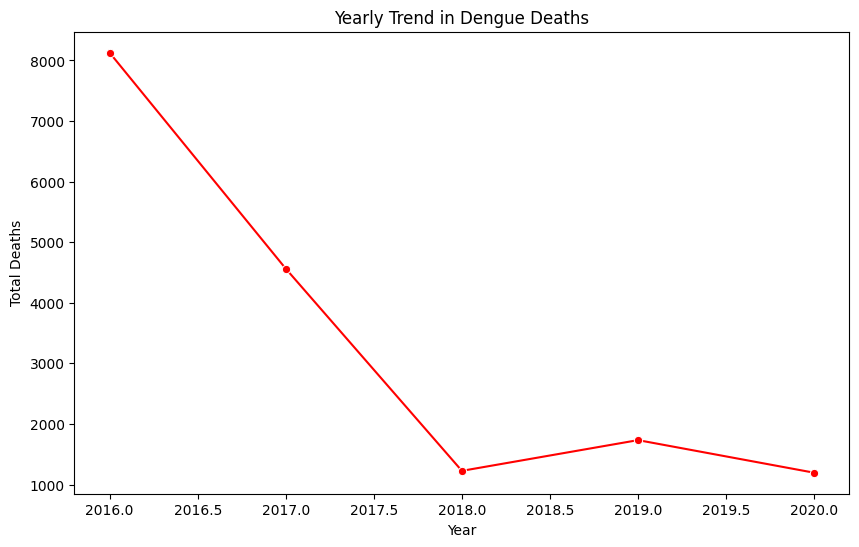

Year
2016    8127
2017    4563
2018    1226
2019    1733
2020    1195
Name: Dengue_Deaths, dtype: int64


In [11]:
yearly_deaths = data.groupby('Year')['Dengue_Deaths'].sum()
plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_deaths.index, y=yearly_deaths.values, marker='o', color='red')
plt.title('Yearly Trend in Dengue Deaths')
plt.xlabel('Year')
plt.ylabel('Total Deaths')
plt.show()

print(f'{yearly_deaths}')

<h1>INSIGHT 6:</h1>
<h3>
The number of yearly Dengue-related deaths has generally decreased over the years, with a significant drop from 8,127 in 2016 to 1,195 in 2020. This trend suggests possible improvements in healthcare, disease management, or public health interventions, even as case numbers fluctuated.</h3>
<hr>

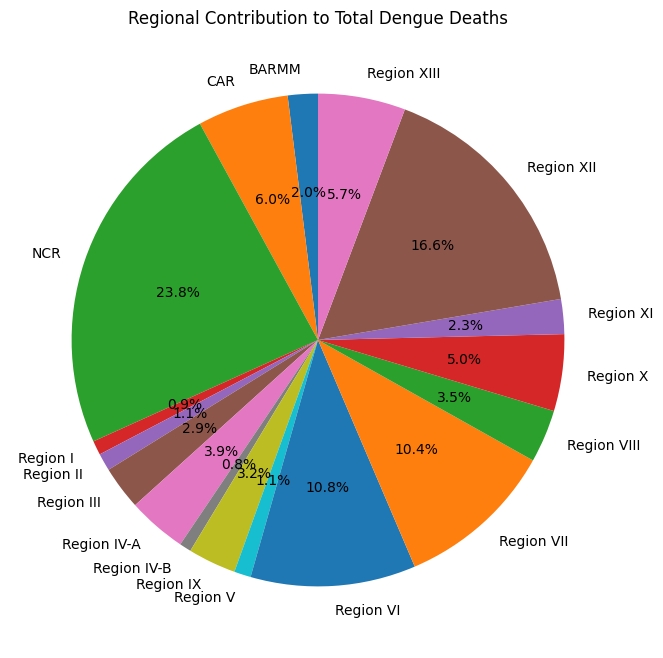

Region
BARMM           332
CAR            1008
NCR            4008
Region I        157
Region II       193
Region III      482
Region IV-A     652
Region IV-B     130
Region IX       532
Region V        185
Region VI      1825
Region VII     1760
Region VIII     585
Region X        848
Region XI       385
Region XII     2796
Region XIII     966
Name: Dengue_Deaths, dtype: int64


In [12]:

region_deaths = data.groupby('Region')['Dengue_Deaths'].sum()
plt.figure(figsize=(8, 8))
plt.pie(region_deaths, labels=region_deaths.index, autopct='%1.1f%%', startangle=90)
plt.title('Regional Contribution to Total Dengue Deaths')
plt.show()

print(f'{region_deaths}')

<h1>INSIGHT 7:</h1>
<h3>Region XII (2,796 deaths) and NCR (4,008 deaths) contribute the most to total Dengue-related deaths, highlighting these regions as critical areas for targeted healthcare interventions. In contrast, Region I (157 deaths) and Region II (193 deaths) show significantly lower death counts, indicating varying levels of disease severity or differences in healthcare response across regions.</h3>
<hr>

<h1>INSIGHT 8:</h1>
<h3>The distribution of dengue deaths across regions shows substantial disparity, with some areas experiencing far heavier impacts than others, suggesting possible differences in population density, outbreak intensity, or effectiveness of local disease control measures. Regions with lower death totals may reflect better early detection and treatment practices, or simply smaller exposed populations.</h3>
<hr>

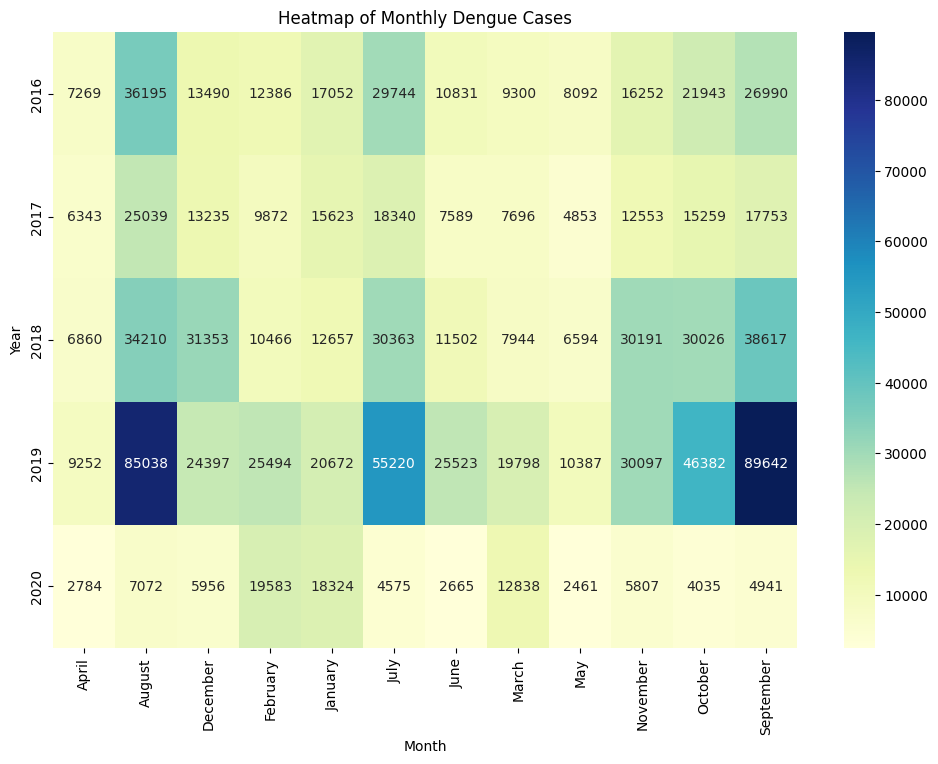

In [15]:
heatmap_data = data.pivot_table(index='Year', columns='Month', values='Dengue_Cases', aggfunc='sum')
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Heatmap of Monthly Dengue Cases')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

<h1>INSIGHT 9:</h1>
<h3>(July-October), with a major outbreak in 2019 (e.g., 89,642 cases in September). In contrast, 2020 saw significantly fewer cases, likely due to public health measures or environmental changes.</h3>
<hr>

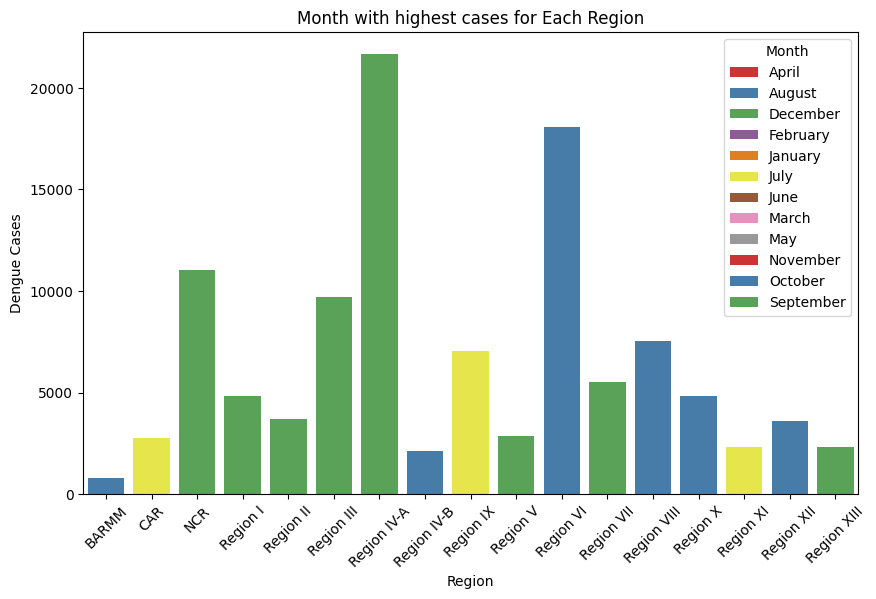

In [19]:
case_month = data.loc[data.groupby('Region')['Dengue_Cases'].idxmax()][['Region', 'Month', 'Dengue_Cases']]
plt.figure(figsize=(10, 6))
sns.barplot(data=case_month, x='Region', y='Dengue_Cases', hue='Month', palette='Set1')
plt.title('Month with highest cases for Each Region')
plt.xlabel('Region')
plt.ylabel('Dengue Cases')
plt.xticks(rotation=45)
plt.show()

<h1>INSIGHT 10:</h1>
<h3>
The month with the highest Dengue cases varies by region but is often clustered around the rainy season (e.g., August, September). For example, Region IV-A reported the highest cases in September (21,658), while Region VI peaked in August (18,090). This seasonal pattern highlights the influence of weather conditions on mosquito breeding and the need for region-specific prevention strategies during peak months.</h3>
<hr>

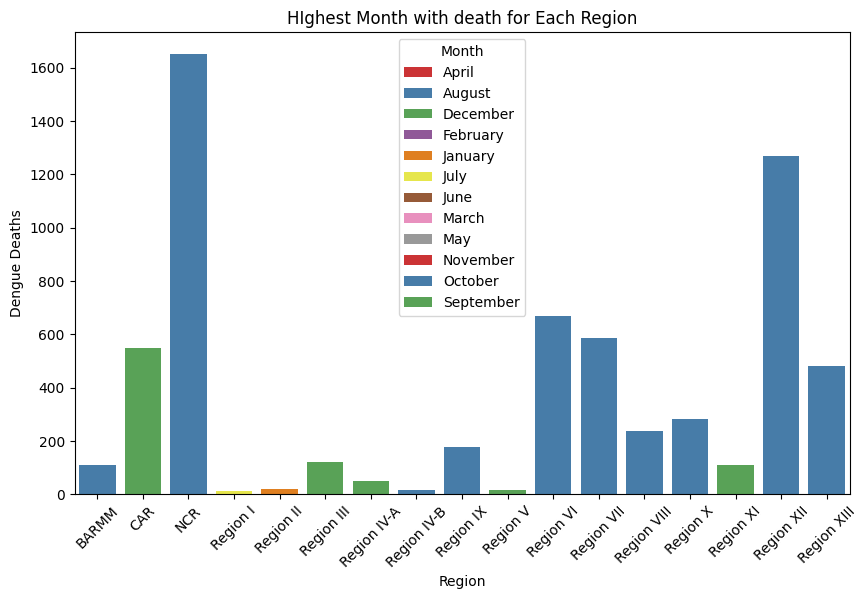

In [21]:
worst_month_death = data.loc[data.groupby('Region')['Dengue_Deaths'].idxmax()][['Region', 'Month', 'Dengue_Deaths']]
plt.figure(figsize=(10, 6))
sns.barplot(data=worst_month_death, x='Region', y='Dengue_Deaths', hue='Month', palette='Set1')
plt.title('HIghest Month with death for Each Region')
plt.xlabel('Region')
plt.ylabel('Dengue Deaths')
plt.xticks(rotation=45)
plt.show()

<h1>INSIGHT 11:</h1>
<h3>The month with the highest Dengue-related deaths in most regions occurs during September or October , coinciding with the peak of the rainy season and higher case numbers. Notably, Region XII had the highest death toll in October (1,270), emphasizing the need for targeted healthcare interventions and mosquito control measures during these critical months to prevent fatalities.</h3>
<hr>

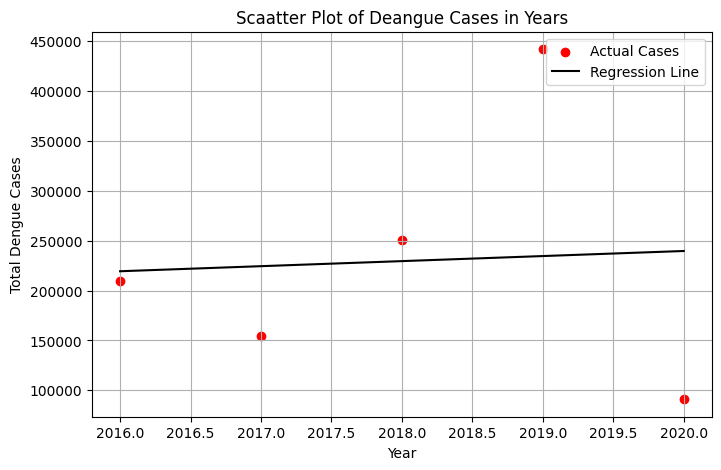

In [31]:
yearly_cases = data.groupby('Year')['Dengue_Cases'].sum().reset_index()


X = yearly_cases[['Year']] 
y = yearly_cases['Dengue_Cases']  

model = LinearRegression()
model.fit(X, y)


yearly_cases['Predicted_Cases'] = model.predict(X)


future_year = np.array([[2021]])
future_prediction = model.predict(future_year)[0]


plt.figure(figsize=(8,5))
plt.scatter(X, y, color='red', label='Actual Cases')
plt.plot(X, yearly_cases['Predicted_Cases'], color='black', label='Regression Line')
plt.title('Scaatter Plot of Deangue Cases in Years')
plt.xlabel('Year')
plt.ylabel('Total Dengue Cases')
plt.legend()
plt.grid(True)
plt.show()

<h1>INSIGHT 11:</h1>
<h3>The regression line shows that dengue cases generally increase over the years, which means the trend is going up even if some years have higher or lower values.</h3>
<hr>



<h1>INSIGHT 12:</h1>
<h3>The model predicts that dengue cases will continue to rise in 2021, suggesting that the upward pattern might keep going unless something changes to control the outbreak.</h3>
<hr>

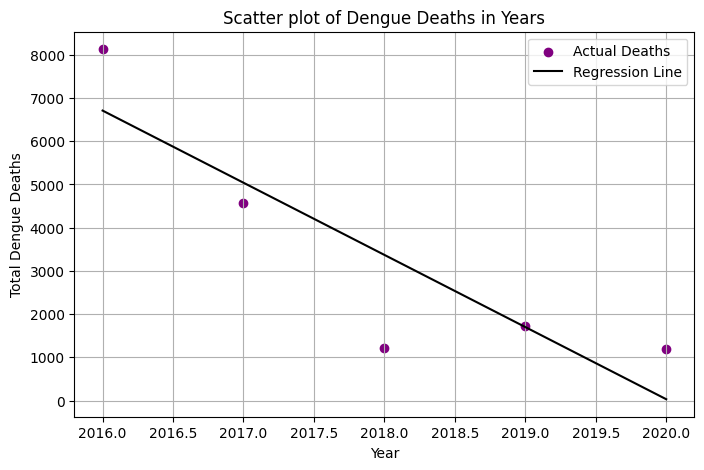

Predicted Dengue Deaths for 2021: -1639


In [30]:
yearly_deaths = data.groupby('Year')['Dengue_Deaths'].sum().reset_index()

X = yearly_deaths[['Year']]
y = yearly_deaths['Dengue_Deaths']

model = LinearRegression()
model.fit(X, y)


yearly_deaths['Predicted_Deaths'] = model.predict(X)


future_year = np.array([[2021]])
future_prediction = model.predict(future_year)[0]


plt.figure(figsize=(8,5))
plt.scatter(X, y, color='purple', label='Actual Deaths')
plt.plot(X, yearly_deaths['Predicted_Deaths'], color='black', label='Regression Line')
plt.title('Scatter plot of Dengue Deaths in Years')
plt.xlabel('Year')
plt.ylabel('Total Dengue Deaths')
plt.legend()
plt.grid(True)
plt.show()

print(f"Predicted Dengue Deaths for 2021: {future_prediction:.0f}")

<h1>INSIGHT 13:</h1>
<h3>
The actual data points are far from the regression line in some years, which suggests that the yearly dengue deaths changed a lot and were not following a steady pattern.
</h3>
<hr>

In [29]:
data["Mortality Rate"] = (data['Dengue_Deaths'] / data['Dengue_Cases']) * 100
X = data[['Dengue_Cases']]   
y = data['Mortality Rate']     


model = LinearRegression()
model.fit(X, y)


y_pred = model.predict(X)
print("Regression Equation:")
print(f"Mortality Rate = ({model.coef_[0]:.6f} * Dengue Cases) + {model.intercept_:.6f}")

r2 = model.score(X, y)
print(f"\nR² Score (Model Accuracy): {r2:.4f}")

Regression Equation:
Mortality Rate = (-0.001037 * Dengue Cases) + 5.179168

R² Score (Model Accuracy): 0.0076


<h1>INSIGHT 14:</h1>
<h3>The regression equation shows that the mortality rate slightly decreases as dengue cases increase, but the change is very small, meaning the number of cases does not strongly affect the mortality rate.</h3>
<hr>

<h1>INSIGHT 15:</h1>
<h3>The R² score of 0.0076 is extremely low, which means the model cannot explain the behavior of the mortality rate and suggests that other factors—not just the number of dengue cases—are influencing how many people die.</h3>
<hr>